In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
train_data = pd.read_csv("/Users/lucasginevro/Downloads/train (1).csv")
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
test_data = pd.read_csv("/Users/lucasginevro/Downloads/test.csv")
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [4]:
# Reviewing dataset shapes
print(f"Train Data Shape: {train_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

Train Data Shape: (1460, 81)
Test Data Shape: (1459, 80)


# Data Cleaning

In [5]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

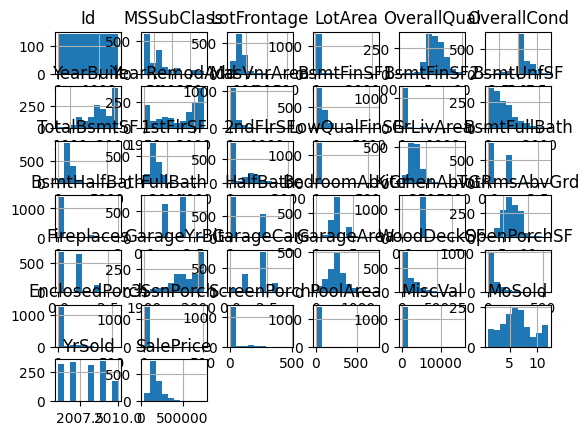

In [6]:
train_data.hist()

In [7]:
# Step 2: Initial missing value check
print("Initial missing values in train data:", train_data.isnull().sum().sum())
print("Initial missing values in test data:", test_data.isnull().sum().sum())

Initial missing values in train data: 7829
Initial missing values in test data: 7878


In [8]:
# Step 3: Handling Missing Values

# Replace NaN with "None" for nominal categorical variables
none_fill_cols = ["Alley", "BsmtFinType1", "BsmtFinType2", "GarageType", "MiscFeature", "Fence", "PoolQC"]
train_data[none_fill_cols] = train_data[none_fill_cols].fillna("None")
test_data[none_fill_cols] = test_data[none_fill_cols].fillna("None")

In [9]:
# Replace NaN in ordinal categorical columns with the lowest ranking category
ordinal_fill_cols = ["BsmtQual", "BsmtExposure", "FireplaceQu", "GarageFinish", "GarageQual", "GarageCond"]
train_data[ordinal_fill_cols] = train_data[ordinal_fill_cols].fillna("NA")
test_data[ordinal_fill_cols] = test_data[ordinal_fill_cols].fillna("NA")

In [10]:
# Ensure LotFrontage is filled using neighborhood median
train_data["LotFrontage"] = train_data.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
test_data["LotFrontage"] = test_data.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

In [11]:
# Step 4: Verify no missing values remain
print("Final missing values in train data:", train_data.isnull().sum().sum())
print("Final missing values in test data:", test_data.isnull().sum().sum())

Final missing values in train data: 999
Final missing values in test data: 1054


In [12]:
# Find columns in train and test with missing values
missing_train = train_data.isnull().sum()
missing_test = test_data.isnull().sum()

# Filter only columns where missing values exist
missing_train = missing_train[missing_train > 0]
missing_test = missing_test[missing_test > 0]

# Display results
print("Missing values in train data:")
print(missing_train)

print("\nMissing values in test data:")
print(missing_test)

Missing values in train data:
MasVnrType     872
MasVnrArea       8
BsmtCond        37
Electrical       1
GarageYrBlt     81
dtype: int64

Missing values in test data:
MSZoning          4
Utilities         2
Exterior1st       1
Exterior2nd       1
MasVnrType      894
MasVnrArea       15
BsmtCond         45
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
KitchenQual       1
Functional        2
GarageYrBlt      78
GarageCars        1
GarageArea        1
SaleType          1
dtype: int64


In [13]:
# Handling missing values

# MasVnrType (categorical) -> "None"
train_data["MasVnrType"].fillna("None", inplace=True)
test_data["MasVnrType"].fillna("None", inplace=True)

# MasVnrArea (numerical) -> 0
train_data["MasVnrArea"].fillna(0, inplace=True)
test_data["MasVnrArea"].fillna(0, inplace=True)

# GarageYrBlt (numerical, no garage) -> Use median year built
median_year_built = train_data["YearBuilt"].median()
train_data["GarageYrBlt"].fillna(median_year_built, inplace=True)
test_data["GarageYrBlt"].fillna(median_year_built, inplace=True)

# BsmtCond (categorical) -> "None"
train_data["BsmtCond"].fillna("None", inplace=True)
test_data["BsmtCond"].fillna("None", inplace=True)

# Electrical (categorical) -> mode
train_data["Electrical"].fillna(train_data["Electrical"].mode()[0], inplace=True)
test_data["Electrical"].fillna(test_data["Electrical"].mode()[0], inplace=True)

# MSZoning, Utilities, Exterior1st, Exterior2nd (categorical) -> mode
for col in ["MSZoning", "Utilities", "Exterior1st", "Exterior2nd"]:
    train_data[col].fillna(train_data[col].mode()[0], inplace=True)
    test_data[col].fillna(test_data[col].mode()[0], inplace=True)

# Basement numerical values -> 0
for col in ["BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath"]:
    train_data[col].fillna(0, inplace=True)
    test_data[col].fillna(0, inplace=True)

# KitchenQual, Functional, SaleType (categorical) -> mode
for col in ["KitchenQual", "Functional", "SaleType"]:
    train_data[col].fillna(train_data[col].mode()[0], inplace=True)
    test_data[col].fillna(test_data[col].mode()[0], inplace=True)

# Garage numerical values -> 0
for col in ["GarageCars", "GarageArea"]:
    train_data[col].fillna(0, inplace=True)
    test_data[col].fillna(0, inplace=True)

# Verify missing values again
print("Missing values in train data:")
print(train_data.isnull().sum().sum())
print("Missing values in test data:")
print(test_data.isnull().sum().sum())

Missing values in train data:
0
Missing values in test data:
0


/var/folders/x3/4t6wq2jj56z96y6l3_b9mm0r0000gn/T/ipykernel_6800/3382719591.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data["MasVnrType"].fillna("None", inplace=True)
/var/folders/x3/4t6wq2jj56z96y6l3_b9mm0r0000gn/T/ipykernel_6800/3382719591.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [14]:
# Reviewing new datasets
print(f"Train Data Shape: {train_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

# Display first 5 rows of train data
import pandas as pd
pd.set_option("display.max_columns", None)  # Ensure we can see all columns
print("Train Data Preview:")
display(train_data.head())

print("Test Data Preview:")
display(test_data.head())

Train Data Shape: (1460, 81)
Test Data Shape: (1459, 80)
Train Data Preview:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000


Test Data Preview:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,None,MnPrv,None,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,None,None,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,None,MnPrv,None,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,None,None,None,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,None,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NA,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,None,None,None,0,1,2010,WD,Normal


In [15]:
# Reviewing new datasets
print(f"Train Data Shape: {train_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

# Display first 5 rows of train data
import pandas as pd
pd.set_option("display.max_columns", None)  # Ensure we can see all columns
print("Train Data Preview:")
display(train_data.head())

print("Test Data Preview:")
display(test_data.head())

Train Data Shape: (1460, 81)
Test Data Shape: (1459, 80)
Train Data Preview:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000


Test Data Preview:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NA,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,None,MnPrv,None,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NA,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,None,None,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,None,MnPrv,None,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,None,None,None,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,None,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NA,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,None,None,None,0,1,2010,WD,Normal


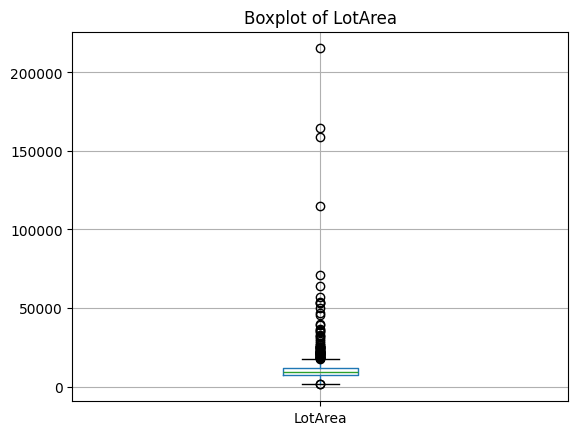

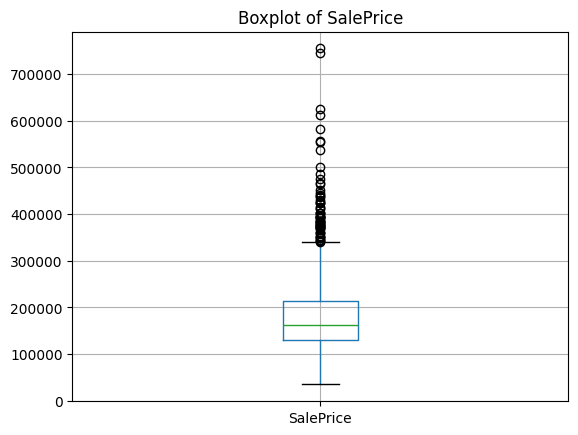

In [16]:
import matplotlib.pyplot as plt

numeric_cols = ["LotArea", "SalePrice"]  # Add other numeric columns
for col in numeric_cols:
    plt.figure()
    train_data.boxplot(column=[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Feature Engineering

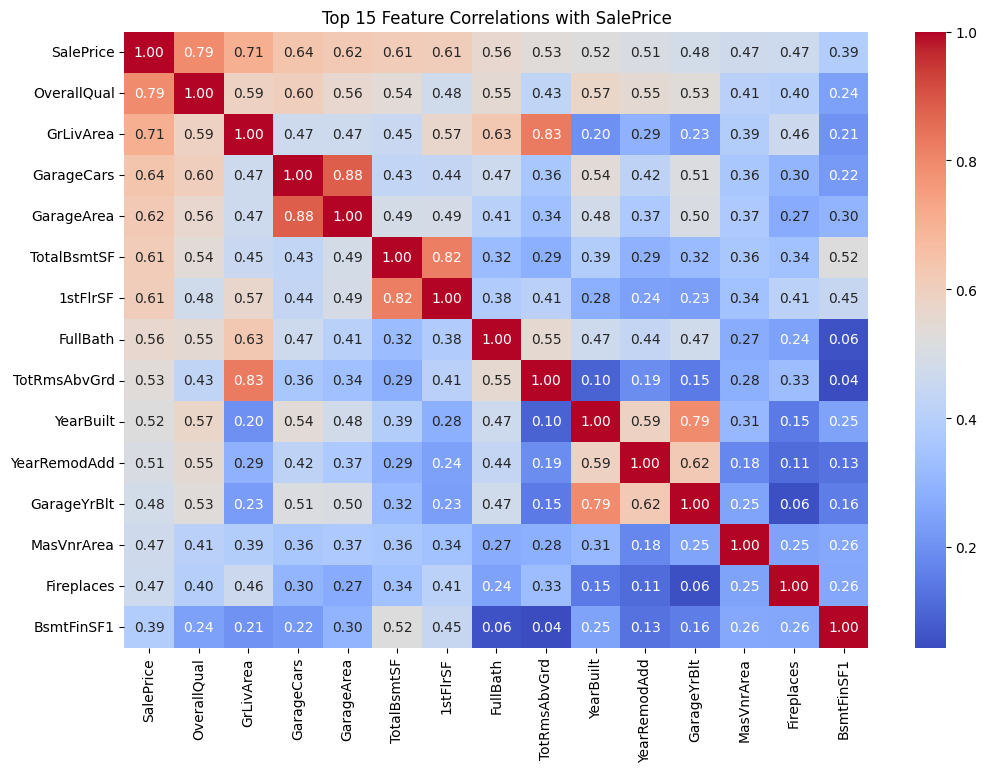

In [17]:
# Select only numeric columns
numeric_cols = train_data.select_dtypes(include=['number']).columns

# Compute correlation matrix using only numerical data
corr_matrix = train_data[numeric_cols].corr()

# Get top 15 features most correlated with SalePrice
top_corr_features = corr_matrix["SalePrice"].abs().sort_values(ascending=False).head(15).index

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(train_data[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top 15 Feature Correlations with SalePrice")
plt.show()

In [18]:
# Evaluating feature importance of categorical variables
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

# Select categorical columns
cat_cols = train_data.select_dtypes(include=['object']).columns

# Temporarily encode categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col])  # Convert categories to numbers
    label_encoders[col] = le

# Compute ANOVA F-Scores
anova_f_scores, _ = f_classif(train_data[cat_cols], train_data["SalePrice"])

# Store results in a DataFrame
anova_results = pd.DataFrame({"Feature": cat_cols, "F-Score": anova_f_scores})
anova_results = anova_results.sort_values(by="F-Score", ascending=False)

# Display the most important categorical features
print(anova_results.head(10))

         Feature   F-Score
18     ExterQual  3.774880
30   KitchenQual  2.904745
21      BsmtQual  2.485452
1         Street  1.870717
34  GarageFinish  1.751114
0       MSZoning  1.742791
33    GarageType  1.639677
28    CentralAir  1.572276
10    Condition2  1.536908
20    Foundation  1.498846


In [19]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train a quick Decision Tree model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_data.drop(columns=["SalePrice"]), train_data["SalePrice"])

# Get feature importances
feature_importance = pd.DataFrame({"Feature": train_data.drop(columns=["SalePrice"]).columns, 
                                   "Importance": rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Display the most important features
print(feature_importance.head(15))

         Feature  Importance
17   OverallQual    0.580235
46     GrLivArea    0.109754
38   TotalBsmtSF    0.037158
44      2ndFlrSF    0.031130
34    BsmtFinSF1    0.029730
61    GarageCars    0.025540
43      1stFlrSF    0.024494
62    GarageArea    0.012584
4        LotArea    0.012052
19     YearBuilt    0.008697
49      FullBath    0.007988
20  YearRemodAdd    0.007800
54  TotRmsAbvGrd    0.007048
12  Neighborhood    0.006858
3    LotFrontage    0.006431


In [20]:
import numpy as np  # Add this at the top if not already imported
import pandas as pd

# Define thresholds
anova_threshold = 1.5  # Drop features with F-score < 1.5
tree_importance_threshold = 0.005  # Drop features with importance < 0.005
correlation_threshold = 0.85  # Drop one of two highly correlated features

# Features from ANOVA (keeping only strong ones)
strong_anova_features = anova_results[anova_results["F-Score"] >= anova_threshold]["Feature"].tolist()

# Features from Decision Tree (keeping only important ones)
strong_tree_features = feature_importance[feature_importance["Importance"] >= tree_importance_threshold]["Feature"].tolist()

# Keep only the features that appear in either ANOVA or Decision Tree selection
selected_features = list(set(strong_anova_features) | set(strong_tree_features))

# Drop ID column if present
if "Id" in train_data.columns:
    train_data.drop(columns=["Id"], inplace=True)
    test_data.drop(columns=["Id"], inplace=True)

# Identify highly correlated features
corr_matrix = train_data[selected_features].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features that are highly correlated
highly_correlated_features = [column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)]
selected_features = [f for f in selected_features if f not in highly_correlated_features]

# Apply feature selection
train_data = train_data[selected_features + ["SalePrice"]]  # Keep SalePrice in train
test_data = test_data[selected_features]  # No SalePrice in test

# Print new shapes after dropping weak features
print(f"Train Data Shape after dropping weak features: {train_data.shape}")
print(f"Test Data Shape after dropping weak features: {test_data.shape}")

Train Data Shape after dropping weak features: (1460, 24)
Test Data Shape after dropping weak features: (1459, 23)


In [21]:
# Reviewing new datasets
print(f"Train Data Shape: {train_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

# Display first 5 rows of train data
import pandas as pd
pd.set_option("display.max_columns", None)  # Ensure we can see all columns
print("Train Data Preview:")
display(train_data.head())

print("Test Data Preview:")
display(test_data.head())

Train Data Shape: (1460, 24)
Test Data Shape: (1459, 23)
Train Data Preview:


,LotFrontage,GarageFinish,TotalBsmtSF,OverallQual,ExterQual,Street,FullBath,CentralAir,1stFlrSF,2ndFlrSF,GarageArea,KitchenQual,YearRemodAdd,Neighborhood,MSZoning,LotArea,BsmtQual,TotRmsAbvGrd,Condition2,GrLivArea,BsmtFinSF1,YearBuilt,GarageType,SalePrice
0,65.0,2,856,7,2,1,2,1,856,854,548,2,2003,5,3,8450,2,8,2,1710,706,2003,1,208500
1,80.0,2,1262,6,3,1,2,1,1262,0,460,3,1976,24,3,9600,2,6,2,1262,978,1976,1,181500
2,68.0,2,920,7,2,1,2,1,920,866,608,2,2002,5,3,11250,2,6,2,1786,486,2001,1,223500
3,60.0,3,756,7,3,1,1,1,961,756,642,2,1970,6,3,9550,4,7,2,1717,216,1915,5,140000
4,84.0,2,1145,8,2,1,2,1,1145,1053,836,2,2000,15,3,14260,2,9,2,2198,655,2000,1,250000


Test Data Preview:


,LotFrontage,GarageFinish,TotalBsmtSF,OverallQual,ExterQual,Street,FullBath,CentralAir,1stFlrSF,2ndFlrSF,GarageArea,KitchenQual,YearRemodAdd,Neighborhood,MSZoning,LotArea,BsmtQual,TotRmsAbvGrd,Condition2,GrLivArea,BsmtFinSF1,YearBuilt,GarageType
0,80.0,Unf,882.0,5,TA,Pave,1,Y,896,0,730.0,TA,1961,NAmes,RH,11622,TA,5,Norm,896,468.0,1961,Attchd
1,81.0,Unf,1329.0,6,TA,Pave,1,Y,1329,0,312.0,Gd,1958,NAmes,RL,14267,TA,6,Norm,1329,923.0,1958,Attchd
2,74.0,Fin,928.0,5,TA,Pave,2,Y,928,701,482.0,TA,1998,Gilbert,RL,13830,Gd,6,Norm,1629,791.0,1997,Attchd
3,78.0,Fin,926.0,6,TA,Pave,2,Y,926,678,470.0,Gd,1998,Gilbert,RL,9978,TA,7,Norm,1604,602.0,1998,Attchd
4,43.0,RFn,1280.0,8,Gd,Pave,2,Y,1280,0,506.0,Gd,1992,StoneBr,RL,5005,Gd,5,Norm,1280,263.0,1992,Attchd


In [22]:
print(train_data[['ExterQual', 'BsmtQual', 'KitchenQual']].head(10))
print(test_data[['ExterQual', 'BsmtQual', 'KitchenQual']].head(10))

   ExterQual  BsmtQual  KitchenQual
0          2         2            2
1          3         2            3
2          2         2            2
3          3         4            2
4          2         2            2
5          3         2            3
6          2         0            2
7          3         2            3
8          3         4            3
9          3         4            3
  ExterQual BsmtQual KitchenQual
0        TA       TA          TA
1        TA       TA          Gd
2        TA       Gd          TA
3        TA       TA          Gd
4        Gd       Gd          Gd
5        TA       Gd          TA
6        TA       Gd          TA
7        TA       Gd          TA
8        TA       Gd          Gd
9        TA       TA          TA


In [23]:
# Ensuring no missing values

print("Missing values in train data:")
print(train_data.isnull().sum().sum())

print("Missing values in test data:")
print(test_data.isnull().sum().sum())

Missing values in train data:
0
Missing values in test data:
0


# Encoding

In [24]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (both nominal and ordinal)
cat_cols = train_data.select_dtypes(include=['object']).columns

# Apply Label Encoding to all categorical columns
for col in cat_cols:
    le = LabelEncoder()
    all_values = list(train_data[col].astype(str)) + list(test_data[col].astype(str))  # Combine train & test to prevent issues
    le.fit(all_values)
    
    train_data[col] = le.transform(train_data[col].astype(str))
    test_data[col] = le.transform(test_data[col].astype(str))

# Final check for missing values
print("Missing values after encoding:", train_data.isnull().sum().sum(), test_data.isnull().sum().sum())

# Confirm dataset shapes
print(f"Train Data Shape: {train_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

Missing values after encoding: 0 0
Train Data Shape: (1460, 24)
Test Data Shape: (1459, 23)


# Linear Regression

Train MSE: 1188581668.70
Train R²: 0.8115
Cross-Validation MSE: 1345400422.18


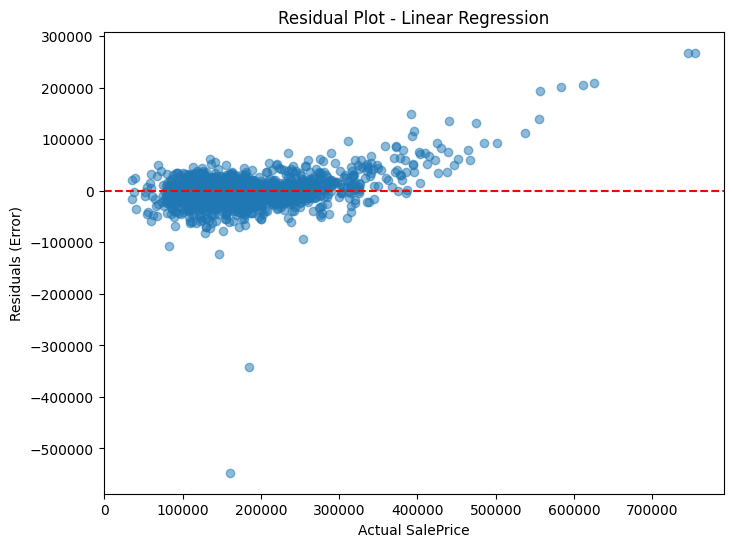

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Separate features and target variable
X_train = train_data.drop(columns=["SalePrice"])
y_train = train_data["SalePrice"]

# Standardize numerical features (helps with stability in Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Predict on training set
y_train_pred = lr_model.predict(X_train_scaled)

# Evaluate the model
mse = mean_squared_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

# Cross-validation for a better performance estimate
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_mse = -np.mean(cv_scores)

# Print results
print(f"Train MSE: {mse:.2f}")
print(f"Train R²: {r2:.4f}")
print(f"Cross-Validation MSE: {cv_mse:.2f}")

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train - y_train_pred, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual SalePrice")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot - Linear Regression")
plt.show()

# Non-Linear Models

In [26]:
pip install pycebox

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
from sklearn.ensemble import RandomForestRegressor

# Define & train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_data.drop(columns=["SalePrice"]), train_data["SalePrice"])

RandomForestRegressor(random_state=42)

In [28]:
# Find non-numeric columns
non_numeric_cols = test_data.select_dtypes(exclude=['number']).columns
print("Categorical columns:", non_numeric_cols.tolist())

Categorical columns: ['GarageFinish', 'ExterQual', 'Street', 'CentralAir', 'KitchenQual', 'Neighborhood', 'MSZoning', 'BsmtQual', 'Condition2', 'GarageType']


In [29]:
# Apply One-Hot Encoding to remaining categorical features
test_data = pd.get_dummies(test_data, drop_first=True)
train_data = pd.get_dummies(train_data, drop_first=True)

# Ensure train & test have the same columns
train_data, test_data = train_data.align(test_data, join="left", axis=1, fill_value=0)

In [30]:
# Ensure SalePrice is removed from test set
if "SalePrice" in test_data.columns:
    test_data = test_data.drop(columns=["SalePrice"])

In [31]:
# Applying RF
# Get predictions using the trained RandomForestRegressor
y_train_pred = rf.predict(train_data.drop(columns=["SalePrice"]))

# Extract actual SalePrice values from the train set
y_train_actual = train_data["SalePrice"]

In [32]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, cross_val_predict
import numpy as np

# Predictions on training set
y_train_pred = rf.predict(train_data.drop(columns=["SalePrice"]))

# Compute MSE and R² on training set
mse_rf_train = mean_squared_error(train_data["SalePrice"], y_train_pred)
r2_rf_train = r2_score(train_data["SalePrice"], y_train_pred)

# Print results
print(f"Random Forest (Train) MSE: {mse_rf_train:.4f}")
print(f"Random Forest (Train) R²: {r2_rf_train:.4f}")

Random Forest (Train) MSE: 115561686.3940
Random Forest (Train) R²: 0.9817


In [33]:
# Define number of folds for cross-validation
cv_folds = 5  

# Compute cross-validated MSE (negative MSE because `cross_val_score` minimizes loss)
mse_cv_scores = -cross_val_score(rf, train_data.drop(columns=["SalePrice"]), train_data["SalePrice"], 
                                 cv=cv_folds, scoring='neg_mean_squared_error')

# Compute cross-validated R²
r2_cv_scores = cross_val_score(rf, train_data.drop(columns=["SalePrice"]), train_data["SalePrice"], 
                               cv=cv_folds, scoring='r2')

# Print cross-validation results
print(f"Random Forest (Cross-Validated) MSE: {np.mean(mse_cv_scores):.4f}")
print(f"Random Forest (Cross-Validated) R²: {np.mean(r2_cv_scores):.4f}")

Random Forest (Cross-Validated) MSE: 873197412.7543
Random Forest (Cross-Validated) R²: 0.8616


/Users/lucasginevro/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


<Figure size 800x600 with 0 Axes>

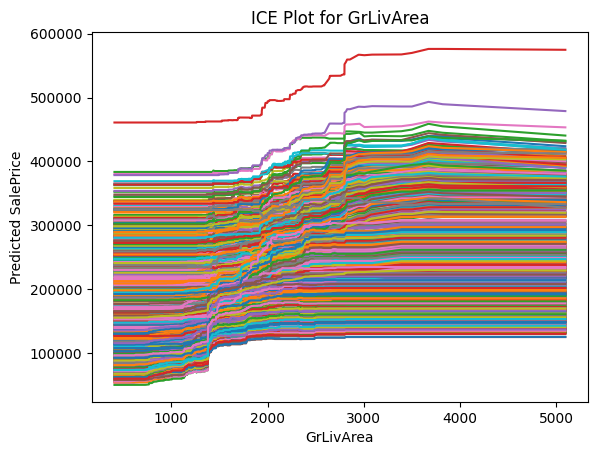

In [34]:
from pycebox.ice import ice, ice_plot  # Import ICE functions

ice_data = ice(data=test_data, column="GrLivArea", predict=rf.predict)
plt.figure(figsize=(8, 6))
ice_plot(ice_data, plot_pdp=True)
plt.title(f"ICE Plot for GrLivArea")
plt.xlabel("GrLivArea")
plt.ylabel("Predicted SalePrice")
plt.show()

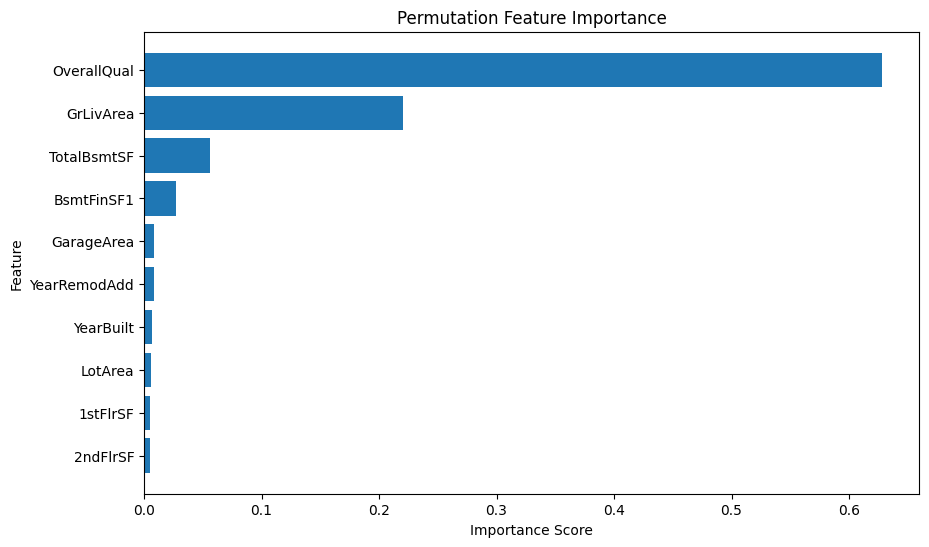

In [35]:
from sklearn.inspection import permutation_importance

# Compute permutation importance
perm_importance = permutation_importance(rf, test_data, rf.predict(test_data), n_repeats=10, random_state=42)

# Convert results to DataFrame
perm_df = pd.DataFrame({"Feature": test_data.columns, "Importance": perm_importance.importances_mean})
perm_df = perm_df.sort_values(by="Importance", ascending=False)

# Plot results
plt.figure(figsize=(10, 6))
plt.barh(perm_df["Feature"][:10], perm_df["Importance"][:10])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

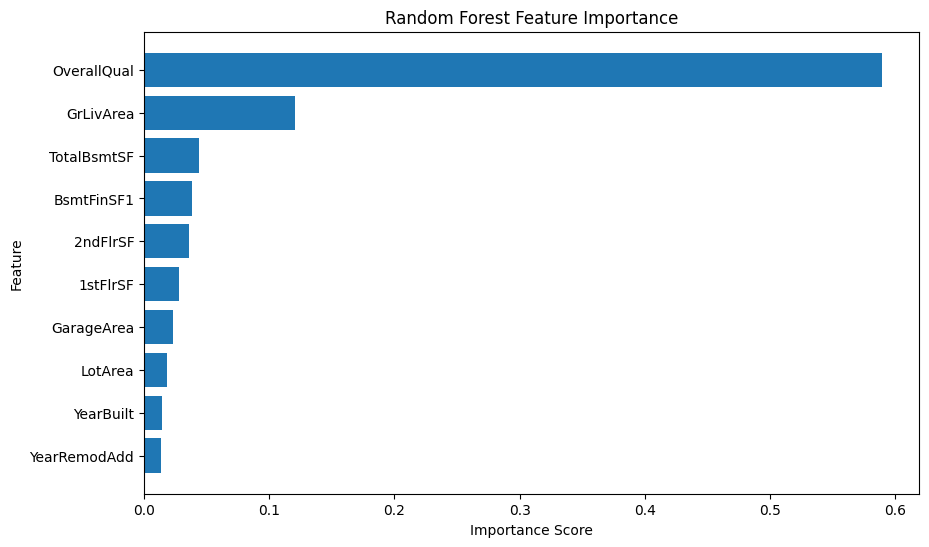

In [36]:
# Get feature importances from RandomForest
tree_importance = pd.DataFrame({
    "Feature": train_data.drop(columns=["SalePrice"]).columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(tree_importance["Feature"][:10], tree_importance["Importance"][:10])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

/Users/lucasginevro/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 1458/1459 [00:58<00:00]        

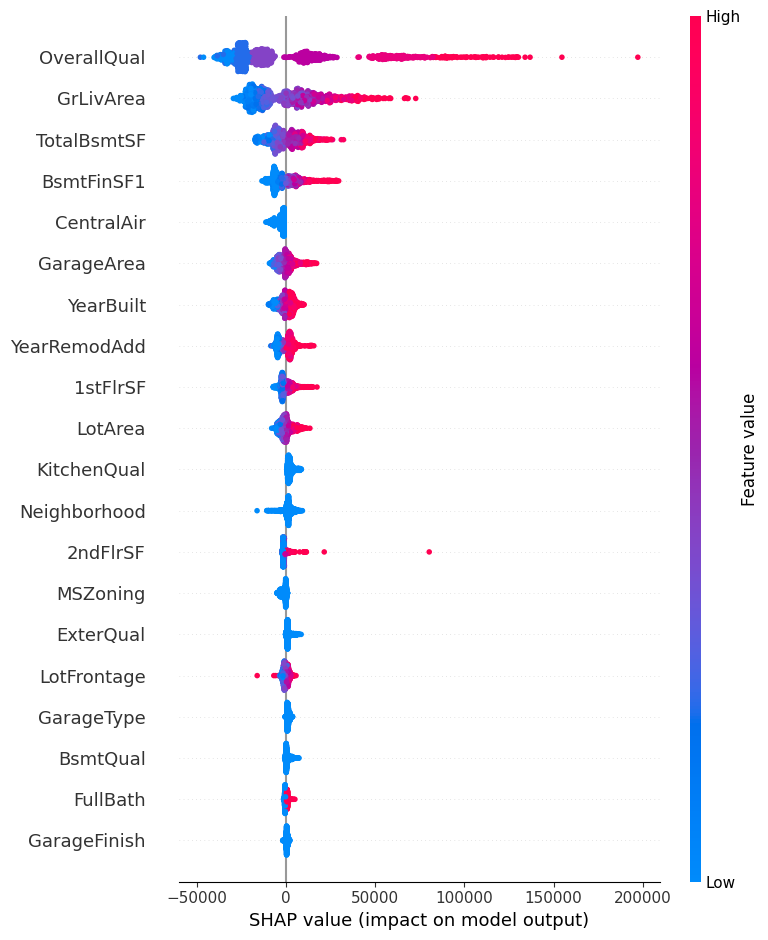

In [37]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.Explainer(rf, train_data.drop(columns=["SalePrice"]))

# Compute SHAP values
shap_values = explainer(test_data)

# Summary Plot (Shows overall feature importance)
shap.summary_plot(shap_values, test_data)
